In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Filtering

In [32]:
df_original=pd.read_csv('src\claims_train.csv')
#Since the density is the continiuous variable, we can drop the Area column
df_original.drop('Area', axis=1, inplace=True)
#Rescale BonusMalus, since in the literature it is said to be between 0.5 and 3.5
df_original['BonusMalus']=df_original['BonusMalus']/100
#Filtering the Exposure since it goes out of bounds (0-1)
df = df_original[df_original['Exposure']<=1]
print(df.shape)
#Filterig VehAge to be less than 25, since on the roads these are the most common vehicles
df = df[(df['VehAge']<=25)]
print(df.shape)
df['Density_scaled'] = StandardScaler().fit_transform(df[['Density']])

regions_remove_outliers = ['R25','R82','R54','R94','R93','R91','R52',
                            'R72','R31','R73','R23','R22','R41','R42',
                            'R83','R21','R74','R43', 'R11']

def remove_outliers_selective(group):
    # Only remove outliers for regions in the list
    if group.name in regions_remove_outliers:
        q1, q3 = group['Density_scaled'].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return group[(group['Density_scaled'] >= lower) & (group['Density_scaled'] <= upper)]
    else:
        return group

df = df.groupby('Region', group_keys=False).apply(remove_outliers_selective)
print(df.shape)

min_malus = 0.95 ** (df['DrivAge']-18)
bad_mal_mask = df['BonusMalus'] >= min_malus
age_avg = df[bad_mal_mask].groupby('DrivAge')['BonusMalus'].mean()
impossible_malus_mask = df['BonusMalus']<0.95**(df['DrivAge']-18)
df.loc[impossible_malus_mask, 'BonusMalus'] = df.loc[impossible_malus_mask, 'DrivAge'].map(age_avg)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\bogda\AppData\Local\Temp\ipykernel_17676\2598603359.py:1: SyntaxWarning: invalid escape sequence '\c'
  df_original=pd.read_csv('src\claims_train.csv')


(541416, 11)
(539373, 11)
(507508, 12)


C:\Users\bogda\AppData\Local\Temp\ipykernel_17676\2598603359.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Region', group_keys=False).apply(remove_outliers_selective)


Separating Data into numerical and categorical

In [33]:
df_clean = df.drop(columns=["IDpol", "ClaimNb", "Exposure","Region"])
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns

Scaling Data for PCA

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[numeric_cols])

Running the PCA on the Data

In [35]:
pca = PCA(n_components=0.9, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)

Original shape: (507508, 6)
Reduced shape: (507508, 4)


Plotting the PCA

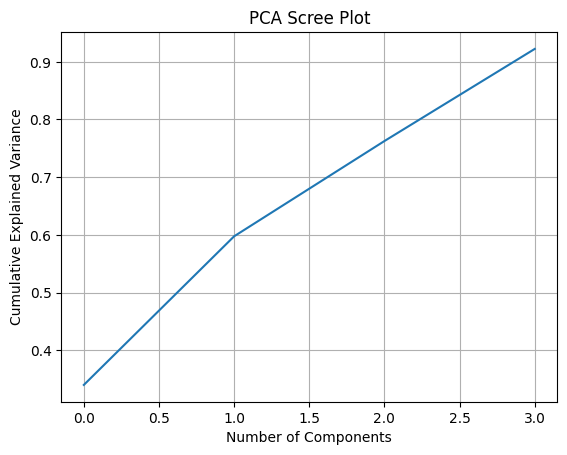

In [36]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.show()

Cleaning the data for Clustering

In [37]:
X_cat = pd.get_dummies(df_clean[categorical_cols], drop_first=True)
X_final = np.hstack([X_pca, X_cat.values])
X_final.shape

(507508, 15)

Clustering

In [ ]:
scores = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_final)
    score = silhouette_score(X_final, labels)
    scores.append((k, score))

best_k = max(scores, key=lambda x: x[1])[0]
print("Best k by silhouette score:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(X_final)

df["Cluster"] = clusters

Best k by silhouette score: 2


ValueError: Length of values (542410) does not match length of index (405763)

Plotting Clustering

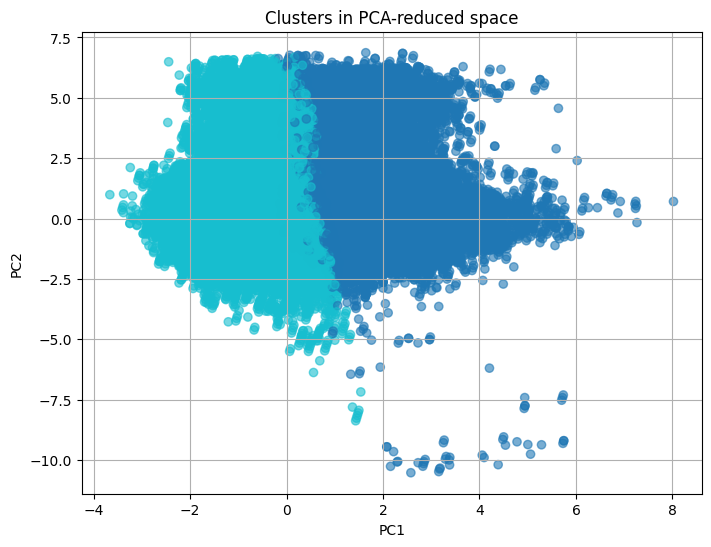

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="tab10", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters in PCA-reduced space")
plt.grid(True)
plt.show()

Printing counts of Clusters

In [10]:
print(df["Cluster"].value_counts())

Cluster
1    400087
0    142323
Name: count, dtype: int64
